# Layer Importance Analysis from Range-Skip Search

This notebook infers layer importance from `layer_skip_results_all.csv`.

Since each run skips a contiguous range of layers, we can estimate which individual layers are most important by:
1. Comparing metric values when a layer is skipped vs not skipped.
2. Fitting an additive linear model over binary skip indicators per layer.
3. Ranking layers by importance (higher degradation when skipped => higher value/cost).

Assumptions:
- No always-include/exclude constraints were used.
- `start_idx` and `end_idx` are valid skip range endpoints per run.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = "layer_skip_results_all.csv"
df = pd.read_csv(CSV_PATH)

required = {"start_idx", "end_idx"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

metric_candidates = ["bin_idx_dist_mean", "l2_mean", "value_diff_mean"]
metric_col = next((c for c in metric_candidates if c in df.columns), None)
if metric_col is None:
    raise ValueError(f"None of expected metric columns found: {metric_candidates}")

# Keep only valid contiguous range rows (drop sentinel/non-range rows if any)
df = df[(df["start_idx"] >= 0) & (df["end_idx"] >= df["start_idx"])].copy()
df["start_idx"] = df["start_idx"].astype(int)
df["end_idx"] = df["end_idx"].astype(int)

df = df.sort_values(["start_idx", "end_idx"]).reset_index(drop=True)

num_layers = int(df["end_idx"].max() + 1)
print(f"Loaded {len(df)} runs from {CSV_PATH}")
print(f"Using metric column: {metric_col}")
print(f"Inferred number of layers: {num_layers}")
df.head()

Loaded 528 runs from layer_skip_results_all.csv
Using metric column: bin_idx_dist_mean
Inferred number of layers: 32


,run_idx,start_idx,end_idx,skip_range,search_skip_layers,total_skip_layers,l2_mean,l2_max,l2_std,value_diff_mean,value_diff_max,bin_idx_dist_mean,bin_idx_dist_max,bin_idx_dist_std,anomalies,has_nan,has_inf,has_extremes,always_exclude_layers,always_include_layers
0,43,0,0,0-0,1,1,0.012545,0.028811,0.008821,0.003939,0.015686,1.107143,9.0,1.508057,False,False,False,False,NaN,NaN
1,44,0,1,0-1,2,2,0.012545,0.028811,0.008821,0.003939,0.015686,1.107143,9.0,1.508057,False,False,False,False,NaN,NaN
2,45,0,2,0-2,3,3,0.012545,0.028811,0.008821,0.003939,0.015686,1.107143,9.0,1.508057,False,False,False,False,NaN,NaN
3,46,0,3,0-3,4,4,0.012545,0.028811,0.008821,0.003939,0.015686,1.107143,9.0,1.508057,False,False,False,False,NaN,NaN
4,47,0,4,0-4,5,5,0.012545,0.028811,0.008821,0.003939,0.015686,1.107143,9.0,1.508057,False,False,False,False,NaN,NaN


## 1) Build Skip Indicator Matrix

For each run, create a binary vector over layers:
- `X[r, l] = 1` if layer `l` was skipped in run `r`
- `X[r, l] = 0` otherwise

This lets us estimate per-layer contribution to metric degradation.

In [2]:
# Build skip indicator matrix X and target vector y
X = np.zeros((len(df), num_layers), dtype=np.float32)
for i, (s, e) in enumerate(zip(df["start_idx"].to_numpy(), df["end_idx"].to_numpy())):
    X[i, s : e + 1] = 1.0

y = df[metric_col].to_numpy(dtype=np.float64)
skip_len = X.sum(axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Avg skipped layers per run:", skip_len.mean())

X shape: (528, 32)
y shape: (528,)
Avg skipped layers per run: 11.333333


## 2) Per-Layer Importance (What These Two Metrics Mean)

We estimate importance of layer $l$ using two complementary signals from your skip-range experiments.

### A) Marginal Delta Importance
Definition:
$$
\Delta_l = \mathbb{E}[y\mid X_l=1] - \mathbb{E}[y\mid X_l=0]
$$
where:
- $y$ is the degradation metric (for example `bin_idx_dist_mean` or `l2_mean`)
- $X_l=1$ means layer $l$ was skipped
- $X_l=0$ means layer $l$ was not skipped

Interpretation:
- Larger positive $\Delta_l$ means skipping layer $l$ tends to hurt output quality more.
- It is easy to understand, but can be confounded because neighboring layers are often skipped together in contiguous ranges.

### B) Regression Effect Importance
Definition (additive model):
$$
y = b_0 + \sum_l w_l X_l + b_1\,\text{skip\_len} + \epsilon
$$
with ridge-regularized least squares.

Interpretation:
- $w_l$ (stored as `regression_effect`) is the estimated unique contribution of skipping layer $l$, after controlling for total skipped length.
- Larger positive $w_l$ means layer $l$ is more important.
- This is typically the better ranking signal when skip patterns are correlated.

### Practical Rule Here
- Use `regression_effect` for final layer ranking.
- Use `marginal_delta` as a sanity-check / interpretability view.
- If both agree on a layer, confidence that the layer is truly important is higher.

In [3]:
# 2a) Marginal delta importance
marginal_delta = np.zeros(num_layers, dtype=np.float64)
for l in range(num_layers):
    mask = X[:, l] > 0
    if mask.any() and (~mask).any():
        marginal_delta[l] = y[mask].mean() - y[~mask].mean()
    else:
        marginal_delta[l] = np.nan

# 2b) Additive regression with skip length as covariate
# Design: [intercept, X(layer indicators), skip_len]
A = np.concatenate(
    [np.ones((len(df), 1), dtype=np.float64), X.astype(np.float64), skip_len[:, None].astype(np.float64)],
    axis=1,
)

ridge_lambda = 1e-4
I = np.eye(A.shape[1], dtype=np.float64)
I[0, 0] = 0.0  # do not regularize intercept
coef = np.linalg.solve(A.T @ A + ridge_lambda * I, A.T @ y)

intercept = coef[0]
reg_layer_effect = coef[1 : 1 + num_layers]
skip_len_coef = coef[-1]

print(f"Intercept: {intercept:.6f}")
print(f"Skip-length coefficient: {skip_len_coef:.6f}")

Intercept: -0.260051
Skip-length coefficient: 2.612859


In [4]:
# Combine results into a ranking table
# In standard decoder blocks, per-layer compute cost is roughly uniform -> cost=1 by default.
layer_cost = np.ones(num_layers, dtype=np.float64)

analysis = pd.DataFrame(
    {
        "layer": np.arange(num_layers, dtype=int),
        "marginal_delta": marginal_delta,
        "regression_effect": reg_layer_effect,
        "cost": layer_cost,
    }
)
analysis["value_cost_marginal"] = analysis["marginal_delta"] / analysis["cost"]
analysis["value_cost_regression"] = analysis["regression_effect"] / analysis["cost"]

# Main ranking uses regression effect (more deconfounded)
ranking = analysis.sort_values("value_cost_regression", ascending=False).reset_index(drop=True)

print("Top 10 most important layers (higher means bigger degradation when skipped):")
ranking.head(10)

Top 10 most important layers (higher means bigger degradation when skipped):


,layer,marginal_delta,regression_effect,cost,value_cost_marginal,value_cost_regression
0,31,79.912766,75.593447,1.0,79.912766,75.593447
1,28,23.532843,1.547351,1.0,23.532843,1.547351
2,26,16.587997,-1.026760,1.0,16.587997,-1.026760
3,0,-0.675025,-1.341143,1.0,-0.675025,-1.341143
4,23,10.605674,-1.376866,1.0,10.605674,-1.376866
5,11,-0.877591,-1.587906,1.0,-0.877591,-1.587906
6,1,-1.243907,-1.667447,1.0,-1.243907,-1.667447
7,6,-1.953512,-1.737798,1.0,-1.953512,-1.737798
8,25,14.261260,-1.782704,1.0,14.261260,-1.782704
9,20,6.058276,-1.993205,1.0,6.058276,-1.993205


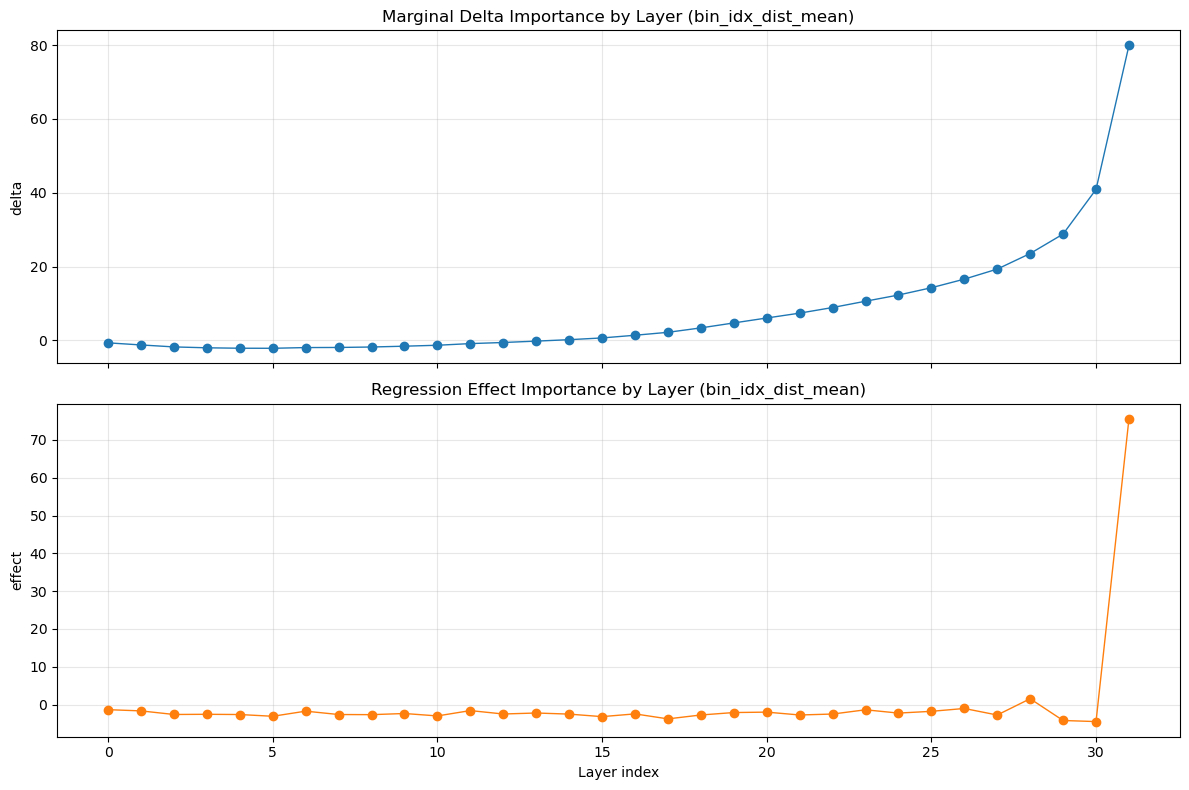

In [5]:
# Visualize per-layer importance curves
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(analysis["layer"], analysis["marginal_delta"], marker="o", linewidth=1)
axes[0].set_title(f"Marginal Delta Importance by Layer ({metric_col})")
axes[0].set_ylabel("delta")
axes[0].grid(True, alpha=0.3)

axes[1].plot(analysis["layer"], analysis["regression_effect"], marker="o", linewidth=1, color="tab:orange")
axes[1].set_title(f"Regression Effect Importance by Layer ({metric_col})")
axes[1].set_xlabel("Layer index")
axes[1].set_ylabel("effect")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

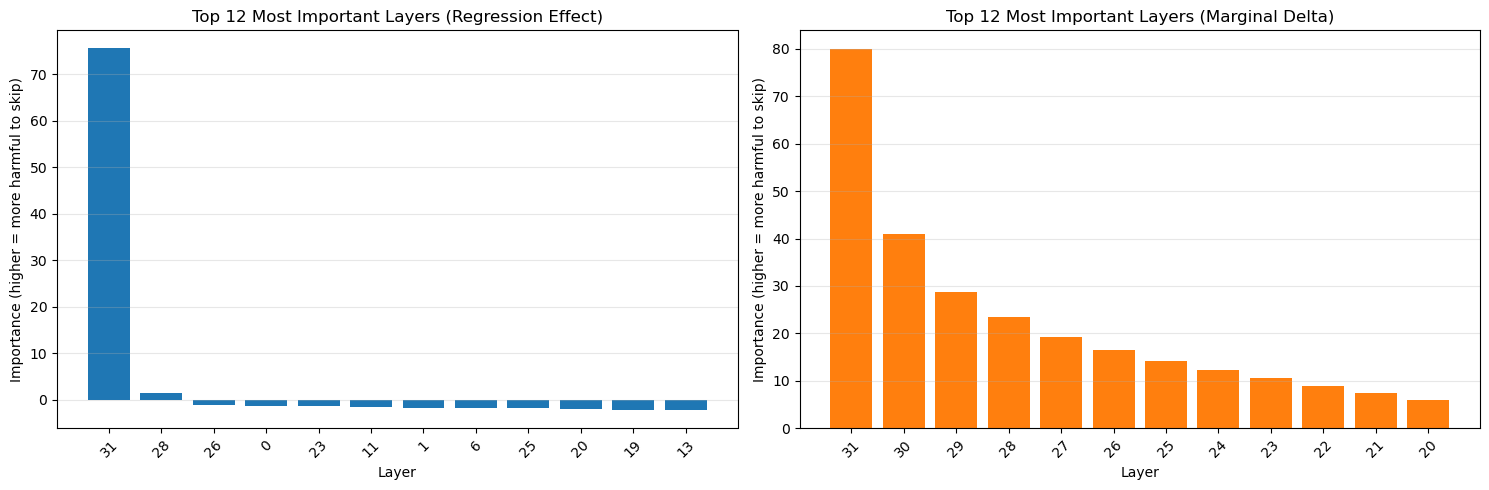

Top 10 layers by regression effect:
 layer  regression_effect  marginal_delta
    31          75.593447       79.912766
    28           1.547351       23.532843
    26          -1.026760       16.587997
     0          -1.341143       -0.675025
    23          -1.376866       10.605674
    11          -1.587906       -0.877591
     1          -1.667447       -1.243907
     6          -1.737798       -1.953512
    25          -1.782704       14.261260
    20          -1.993205        6.058276


In [6]:
# Visual summary: make the most important individual layers obvious
TOP_LAYERS = 12

top_reg = ranking.head(TOP_LAYERS).copy()
top_marg = analysis.sort_values("marginal_delta", ascending=False).head(TOP_LAYERS).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(top_reg["layer"].astype(str), top_reg["regression_effect"])
axes[0].set_title(f"Top {TOP_LAYERS} Most Important Layers (Regression Effect)")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Importance (higher = more harmful to skip)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(top_marg["layer"].astype(str), top_marg["marginal_delta"], color="tab:orange")
axes[1].set_title(f"Top {TOP_LAYERS} Most Important Layers (Marginal Delta)")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Importance (higher = more harmful to skip)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Top 10 layers by regression effect:")
print(ranking[["layer", "regression_effect", "marginal_delta"]].head(10).to_string(index=False))

## 3) Combination Analysis (Pairs, Triplets, ... up to K)

This section ranks layer combinations by estimated usefulness.

Definitions:
- **Estimated score**: sum of per-layer regression effects (additive approximation).
- **Observed score**: exact metric from CSV if that exact skip set exists.

Because your search data uses contiguous skipped ranges, exact observed values mainly exist for contiguous combinations. Non-contiguous combinations are estimated from the additive model.

In [7]:
from itertools import combinations

# Config
MAX_COMBO_SIZE = 4          # analyze combos of size 2..MAX_COMBO_SIZE
TOP_K_PER_SIZE = 20         # return top-k combos for each size
CANDIDATE_POOL_SIZE = 16    # restrict combinatorial search to top-N important layers
USE_ABSOLUTE_EFFECT = False # False: prefer positive degradation effects only

# Layer effect vector from regression model (already computed earlier)
layer_effect = analysis["regression_effect"].to_numpy(dtype=np.float64)

if USE_ABSOLUTE_EFFECT:
    candidate_order = np.argsort(-np.abs(layer_effect))
else:
    candidate_order = np.argsort(-layer_effect)

candidate_layers = candidate_order[:CANDIDATE_POOL_SIZE]
print("Candidate layers for combo search:", candidate_layers.tolist())

# Build exact observed mapping from CSV rows: skip set tuple -> observed metric
# (With contiguous-range search, these are contiguous combos by construction.)
observed_map = {}
for _, row in df.iterrows():
    s, e = int(row["start_idx"]), int(row["end_idx"])
    key = tuple(range(s, e + 1))
    observed_map[key] = float(row[metric_col])


def combo_record(combo):
    combo = tuple(sorted(int(x) for x in combo))
    est = float(layer_effect[list(combo)].sum())
    obs = observed_map.get(combo, np.nan)

    # Robust contiguous check: span length equals number of elements.
    # Equivalent to all adjacent diffs being 1, but avoids dtype edge-cases.
    contiguous = int((combo[-1] - combo[0] + 1) == len(combo))

    return {
        "combo_size": len(combo),
        "combo": combo,
        "start": combo[0],
        "end": combo[-1],
        "is_contiguous": contiguous,
        "has_observed_score": int(combo in observed_map),
        "estimated_score": est,
        "observed_score": obs,
        "value_per_layer_est": est / len(combo),
    }

all_combo_tables = []
for m in range(2, MAX_COMBO_SIZE + 1):
    rows = [combo_record(c) for c in combinations(candidate_layers, m)]
    table = pd.DataFrame(rows)
    table = table.sort_values("estimated_score", ascending=False).reset_index(drop=True)

    # Sanity summary for this size
    n_contig = int(table["is_contiguous"].sum())
    n_obs = int(table["has_observed_score"].sum())
    print(f"size={m}: contiguous={n_contig}/{len(table)}, observed={n_obs}/{len(table)}")

    top_table = table.head(TOP_K_PER_SIZE).copy()
    all_combo_tables.append(top_table)

combo_ranked = pd.concat(all_combo_tables, ignore_index=True)
combo_ranked.head(20)

Candidate layers for combo search: [31, 28, 26, 0, 23, 11, 1, 6, 25, 20, 19, 13, 24, 9, 16, 12]
size=2: contiguous=7/120, observed=7/120
size=3: contiguous=3/560, observed=3/560
size=4: contiguous=1/1820, observed=1/1820


,combo_size,combo,start,end,is_contiguous,has_observed_score,estimated_score,observed_score,value_per_layer_est
0,2,"(28, 31)",28,31,0,0,77.140799,NaN,38.570399
1,2,"(26, 31)",26,31,0,0,74.566687,NaN,37.283344
2,2,"(0, 31)",0,31,0,0,74.252304,NaN,37.126152
3,2,"(23, 31)",23,31,0,0,74.216581,NaN,37.108290
4,2,"(11, 31)",11,31,0,0,74.005541,NaN,37.002770
5,2,"(1, 31)",1,31,0,0,73.926000,NaN,36.963000
6,2,"(6, 31)",6,31,0,0,73.855649,NaN,36.927825
7,2,"(25, 31)",25,31,0,0,73.810743,NaN,36.905372
8,2,"(20, 31)",20,31,0,0,73.600242,NaN,36.800121
9,2,"(19, 31)",19,31,0,0,73.488771,NaN,36.744386


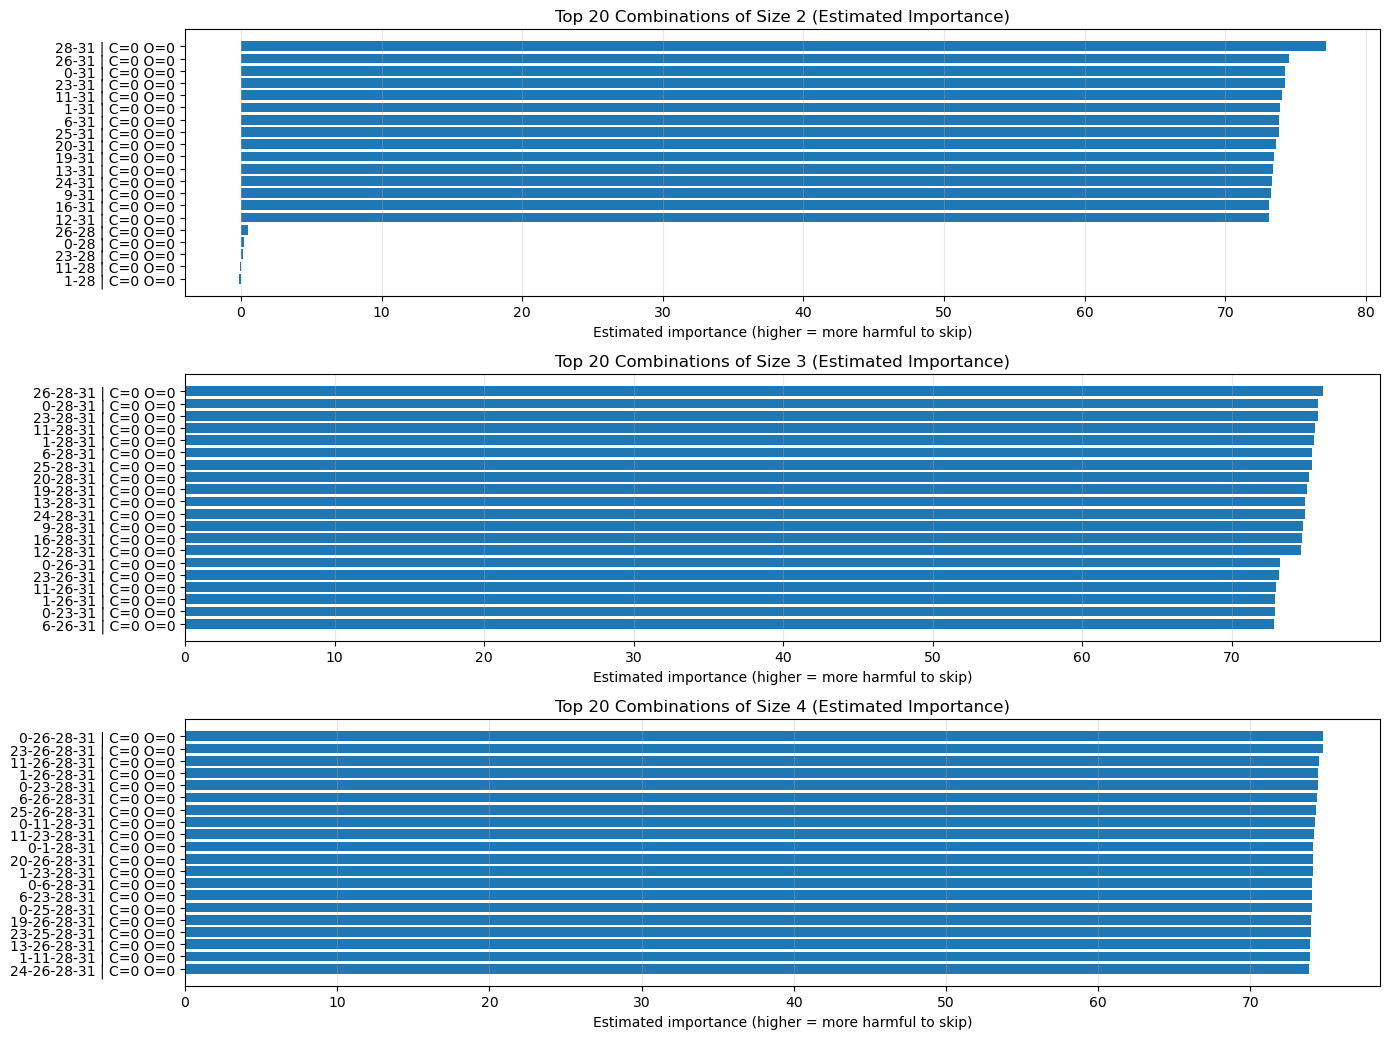

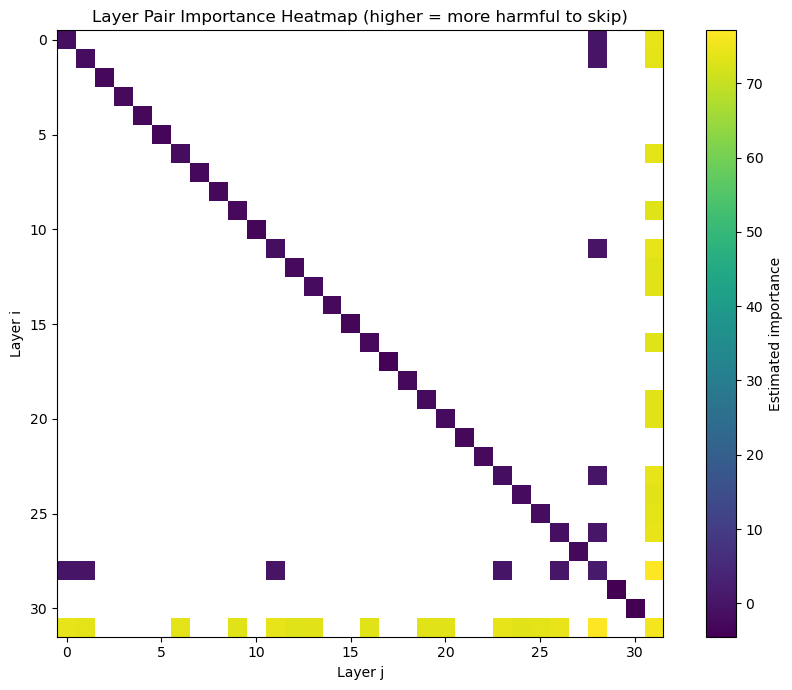

Most useful pair combinations (top K):
   combo  estimated_score  value_per_layer_est  observed_score  is_contiguous  has_observed_score
(28, 31)        77.140799            38.570399             NaN              0                   0
(26, 31)        74.566687            37.283344             NaN              0                   0
 (0, 31)        74.252304            37.126152             NaN              0                   0
(23, 31)        74.216581            37.108290             NaN              0                   0
(11, 31)        74.005541            37.002770             NaN              0                   0
 (1, 31)        73.926000            36.963000             NaN              0                   0
 (6, 31)        73.855649            36.927825             NaN              0                   0
(25, 31)        73.810743            36.905372             NaN              0                   0
(20, 31)        73.600242            36.800121             NaN              0  

In [8]:
# Combination plots (no CSV output): top combos + pair heatmap

# 1) Top combinations per size as horizontal bar charts
n_sizes = MAX_COMBO_SIZE - 1
fig, axes = plt.subplots(n_sizes, 1, figsize=(14, 3.5 * n_sizes), squeeze=False)

for idx, m in enumerate(range(2, MAX_COMBO_SIZE + 1)):
    sub = combo_ranked[combo_ranked["combo_size"] == m].head(TOP_K_PER_SIZE).copy()
    sub = sub.sort_values("estimated_score", ascending=True)

    # Mark whether combo is contiguous and has exact observed metric in CSV
    labels = sub.apply(
        lambda r: f"{'-'.join(map(str, r['combo']))} | C={int(r['is_contiguous'])} O={int(r['has_observed_score'])}",
        axis=1,
    )

    ax = axes[idx, 0]
    ax.barh(labels, sub["estimated_score"])
    ax.set_title(f"Top {TOP_K_PER_SIZE} Combinations of Size {m} (Estimated Importance)")
    ax.set_xlabel("Estimated importance (higher = more harmful to skip)")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# 2) Pair heatmap: estimated importance for skipping layer pair (i, j)
pairs = combo_ranked[combo_ranked["combo_size"] == 2].copy()
if len(pairs) == 0:
    print("No pair data available in combo_ranked.")
else:
    n = num_layers
    mat = np.full((n, n), np.nan, dtype=np.float64)

    # Fill matrix with estimated pair scores for available pairs
    for _, row in pairs.iterrows():
        i, j = row["combo"]
        score = row["estimated_score"]
        mat[i, j] = score
        mat[j, i] = score

    # Diagonal can show single-layer regression effect for reference
    diag = analysis.set_index("layer")["regression_effect"].to_dict()
    for i in range(n):
        mat[i, i] = diag.get(i, np.nan)

    plt.figure(figsize=(9, 7))
    im = plt.imshow(mat, cmap="viridis", interpolation="nearest")
    plt.colorbar(im, label="Estimated importance")
    plt.title("Layer Pair Importance Heatmap (higher = more harmful to skip)")
    plt.xlabel("Layer j")
    plt.ylabel("Layer i")
    plt.tight_layout()
    plt.show()

    top_pairs = pairs.sort_values("estimated_score", ascending=False).head(TOP_K_PER_SIZE).copy()
    print("Most useful pair combinations (top K):")
    print(
        top_pairs[
            [
                "combo",
                "estimated_score",
                "value_per_layer_est",
                "observed_score",
                "is_contiguous",
                "has_observed_score",
            ]
        ].to_string(index=False)
    )